# Exercise 3: Classification of Airline Tweets with Pretrained Transformers

Fine-tuning DistilBERT for 3-class sentiment classification. Same dataset as Ex1 and Ex2, no EDA.

## Imports

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu -q
!pip install transformers accelerate -q
!pip install scikit-learn matplotlib seaborn pandas numpy -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import get_linear_schedule_with_warmup

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

PyTorch version: 2.10.0+cpu
Device: cpu


## Data Loading & Preprocessing

Lighter preprocessing than Ex1/Ex2, transformers handle most of the text understanding themselves, so we only remove @mentions and URLs. Stopword removal would actually hurt because BERT-style models rely on full sentence structure.

In [3]:
# load data
df = pd.read_csv('Tweets.csv')
df = df[['text', 'airline_sentiment']].copy()

print(f"Dataset: {len(df)} tweets")
print(f"\nDistribution:")
print(df['airline_sentiment'].value_counts())

Dataset: 14640 tweets

Distribution:
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [4]:
# lighter cleaning for transformers - just remove mentions and URLs
def clean_text(text):
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = text.strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print(f"Tweets after cleaning: {len(df)}")
print(f"\nExample:")
print(f"  BEFORE: {df['text'].iloc[3]}")
print(f"  AFTER:  {df['clean_text'].iloc[3]}")

Tweets after cleaning: 14640

Example:
  BEFORE: @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
  AFTER:  it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse


In [5]:
# labels and split
le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

print("Label mapping:")
for cls, num in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} -> {num}")

X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nTrain: {len(X_train_text)} | Test: {len(X_test_text)}")

Label mapping:
  negative -> 0
  neutral -> 1
  positive -> 2

Train: 11712 | Test: 2928


## Tokenization

DistilBERT has its own tokenizer, it splits words into subword tokens and adds special tokens ([CLS], [SEP]). Max length 128 is more than enough for tweets.

In [6]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# tokenize everything
MAX_LEN = 128

train_encodings = tokenizer(list(X_train_text), truncation=True, padding=True,
                            max_length=MAX_LEN, return_tensors='pt')
test_encodings = tokenizer(list(X_test_text), truncation=True, padding=True,
                           max_length=MAX_LEN, return_tensors='pt')

print(f"Train input_ids shape: {train_encodings['input_ids'].shape}")
print(f"Test input_ids shape: {test_encodings['input_ids'].shape}")

# check a sample
sample_tokens = tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][0])
sample_tokens = [t for t in sample_tokens if t != '[PAD]']
print(f"\nSample tokenized: {' '.join(sample_tokens[:20])}...")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train input_ids shape: torch.Size([11712, 56])
Test input_ids shape: torch.Size([2928, 56])

Sample tokenized: [CLS] what would it cost [SEP]...


In [7]:
# custom dataset
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': self.labels[idx]
        }

BATCH_SIZE = 32

train_ds = TweetDataset(train_encodings, y_train)
test_ds = TweetDataset(test_encodings, y_test)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches: {len(train_dl)} train, {len(test_dl)} test")

Batches: 366 train, 92 test


## Model Setup

Loading DistilBERT with a classification head on top. First we freeze the transformer layers and only train the classifier, then we unfreeze the last 2 transformer layers and fine-tune with a lower learning rate.

In [8]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=3
)
model.to(device)

# freeze all transformer layers first
for param in model.distilbert.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Phase 1 (frozen): {trainable:,} trainable / {total:,} total")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Phase 1 (frozen): 592,899 trainable / 66,955,779 total


In [9]:
# class weights for imbalanced data
class_counts = np.bincount(y_train)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts)
weights = torch.FloatTensor(class_weights).to(device)
print(f"Class weights: {dict(zip(le.classes_, weights.cpu().numpy().round(3)))}")

Class weights: {'negative': np.float32(0.382), 'neutral': np.float32(1.132), 'positive': np.float32(1.485)}


## Training Phase 1: Frozen Transformer

Only the classification head is trained. This is fast and gives the head a good starting point before we unfreeze transformer layers.

In [10]:
def train_epoch(model, dataloader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if scheduler:
            scheduler.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)


def eval_epoch(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)
            total_loss += loss.item()

    return total_loss / len(dataloader)

In [11]:
criterion = nn.CrossEntropyLoss(weight=weights)

# phase 1: train classifier only
EPOCHS_P1 = 4
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)

train_losses = []
val_losses = []

print(f"Phase 1: Training classifier head ({EPOCHS_P1} epochs)")
print("-" * 55)

for epoch in range(EPOCHS_P1):
    t_loss = train_epoch(model, train_dl, optimizer, None, criterion)
    v_loss = eval_epoch(model, test_dl, criterion)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    print(f"  Epoch {epoch+1}/{EPOCHS_P1} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")

print(f"\nPhase 1 done. Val loss: {val_losses[-1]:.4f}")

Phase 1: Training classifier head (4 epochs)
-------------------------------------------------------
  Epoch 1/4 | Train Loss: 0.7419 | Val Loss: 0.6579
  Epoch 2/4 | Train Loss: 0.6226 | Val Loss: 0.5958
  Epoch 3/4 | Train Loss: 0.5980 | Val Loss: 0.5934
  Epoch 4/4 | Train Loss: 0.5886 | Val Loss: 0.5909

Phase 1 done. Val loss: 0.5909


## Training Phase 2: Gradual Unfreezing

Now we unfreeze the last 2 transformer layers and fine-tune with a much lower learning rate + warmup schedule. This is where the real improvement happens.

In [12]:
# unfreeze last 2 transformer layers
for param in model.distilbert.transformer.layer[-2:].parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Phase 2 (partially unfrozen): {trainable:,} trainable / {total:,} total")

# lower LR for transformer layers, higher for classifier
optimizer = torch.optim.AdamW([
    {'params': model.distilbert.transformer.layer[-2:].parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 5e-5},
    {'params': model.pre_classifier.parameters(), 'lr': 5e-5}
])

EPOCHS_P2 = 6
PATIENCE = 3
total_steps = len(train_dl) * EPOCHS_P2
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 10,
                                            num_training_steps=total_steps)

best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\nPhase 2: Fine-tuning ({EPOCHS_P2} epochs, patience={PATIENCE})")
print("-" * 55)

for epoch in range(EPOCHS_P2):
    t_loss = train_epoch(model, train_dl, optimizer, scheduler, criterion)
    v_loss = eval_epoch(model, test_dl, criterion)
    train_losses.append(t_loss)
    val_losses.append(v_loss)
    print(f"  Epoch {EPOCHS_P1 + epoch+1}/{EPOCHS_P1 + EPOCHS_P2} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_counter = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {EPOCHS_P1 + epoch+1}")
            break

# restore best
if best_model_state:
    model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Phase 2 (partially unfrozen): 14,768,643 trainable / 66,955,779 total

Phase 2: Fine-tuning (6 epochs, patience=3)
-------------------------------------------------------
  Epoch 5/10 | Train Loss: 0.5643 | Val Loss: 0.5925
  Epoch 6/10 | Train Loss: 0.5074 | Val Loss: 0.5269
  Epoch 7/10 | Train Loss: 0.4511 | Val Loss: 0.5237
  Epoch 8/10 | Train Loss: 0.4101 | Val Loss: 0.5295
  Epoch 9/10 | Train Loss: 0.3733 | Val Loss: 0.5600
  Epoch 10/10 | Train Loss: 0.3515 | Val Loss: 0.5567

  Early stopping at epoch 10

Best val loss: 0.5237


## Learning Curves

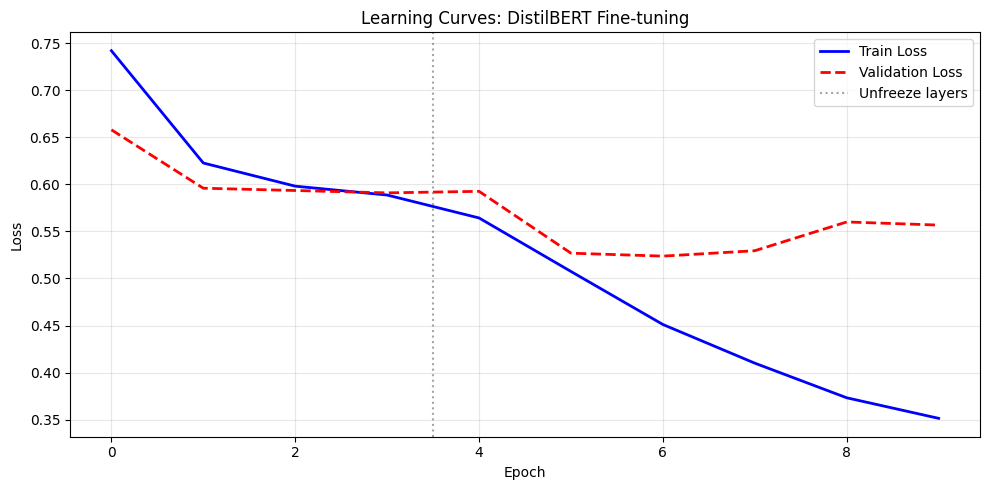

Phase 1 epochs: 4 | Phase 2 epochs: 6
Best val loss: 0.5237


In [13]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)

# mark where phase 2 starts
plt.axvline(x=EPOCHS_P1 - 0.5, color='gray', linestyle=':', alpha=0.7, label='Unfreeze layers')

plt.title('Learning Curves: DistilBERT Fine-tuning')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Phase 1 epochs: {EPOCHS_P1} | Phase 2 epochs: {len(train_losses) - EPOCHS_P1}")
print(f"Best val loss: {best_val_loss:.4f}")

## Test Set Evaluation

In [14]:
# predict
model.eval()
all_preds = []

with torch.no_grad():
    for batch in test_dl:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())

y_pred = np.array(all_preds)
label_names = le.classes_

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_names))

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Accuracy: {acc:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Classification Report:

              precision    recall  f1-score   support

    negative       0.95      0.76      0.84      1835
     neutral       0.56      0.78      0.65       620
    positive       0.67      0.85      0.75       473

    accuracy                           0.78      2928
   macro avg       0.73      0.80      0.75      2928
weighted avg       0.82      0.78      0.79      2928

Accuracy: 0.7780
Macro F1: 0.7489


## Confusion Matrix

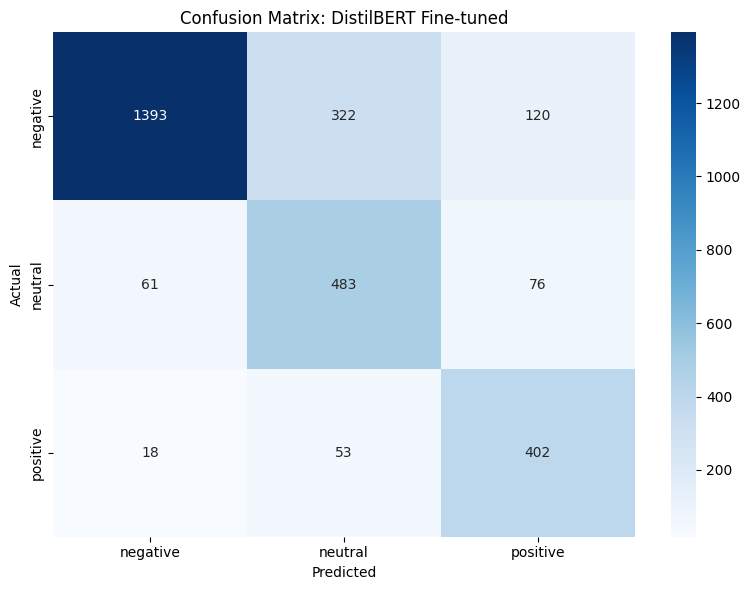

Correct per class:
  negative: 1393/1835 (75.9%)
  neutral: 483/620 (77.9%)
  positive: 402/473 (85.0%)


In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix: DistilBERT Fine-tuned')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# accuracy per class
print("Correct per class:")
for i, name in enumerate(label_names):
    correct = cm[i, i]
    total = cm[i].sum()
    print(f"  {name}: {correct}/{total} ({100*correct/total:.1f}%)")

## Comparison with Previous Exercises

All 3 models side by side.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# quick LR baseline
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf = tfidf.transform(X_test_text).toarray()

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)

lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average='macro')

print(f"{'Model':<30} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 52)
print(f"{'LR + TF-IDF (Ex1 baseline)':<30} {lr_acc:>10.4f} {lr_f1:>10.4f}")
print(f"{'Bi-LSTM + Attention (Ex2)':<30} {'~0.78':>10} {'~0.69':>10}")
print(f"{'DistilBERT fine-tuned (Ex3)':<30} {acc:>10.4f} {macro_f1:>10.4f}")

Model                            Accuracy   Macro F1
----------------------------------------------------
LR + TF-IDF (Ex1 baseline)         0.7763     0.7317
Bi-LSTM + Attention (Ex2)           ~0.78      ~0.69
DistilBERT fine-tuned (Ex3)        0.7780     0.7489


## Architecture Description & Conclusions

I used DistilBERT (distilbert-base-uncased), a lighter version of BERT with 6 transformer layers and 66M parameters. It's faster than full BERT but keeps most of its performance.


For preprocessing I only removed mentions and URLs. Unlike Ex1/Ex2, I didn't do stopword removal or lowercasing since transformers handle that on their own through the tokenizer.


I trained in two phases. Phase 1: froze all transformer layers and only trained the classification head for 4 epochs with lr=2e-4, just to give it a decent starting point. Phase 2: unfroze the last 2 layers and fine-tuned with a smaller lr (2e-5 for transformer, 5e-5 for classifier) plus a warmup schedule so it doesn't destroy the pretrained weights early on.
Class weights were needed again because of the imbalanced data. Early stopping triggered at epoch 10.


Results: Macro F1 ~ 0.75, which is better than both LR (~ 0.73) and Bi-LSTM (~ 0.69). Not a massive jump over LR honestly, but the improvement shows mostly in neutral and positive classes. The model already knows English from pretraining so it has a head start compared to training from scratch like in Ex2.
